# Capstone Project: Advanced Ensembles, Class Imbalance, Interpretability & Deployment
## Week 4 Day 5 
**Objective**: Bring together all modern machine learning workflows to build, evaluate, interpret, and deploy a robust production pipeline for the **Adult Census Income dataset** (predicting income $>50\text{K}$ vs. $\le 50\text{K}$).

### Key Notebook Sections:
1. **Task 1: Train & Compare Ensemble Models**: Compare `RandomForestClassifier`, `HistGradientBoostingClassifier`, and a **Stacking Classifier** against single tuned baselines.
2. **Task 2: Systematically Address Class Imbalance**: Evaluate 3 cross-validated imbalance strategies (`class_weight='balanced'`, SMOTE, cost-sensitive boosting) and optimize decision thresholds.
3. **Task 3: Interpretability & Subgroup Fairness Audit**: Global SHAP / Permutation Importance, 3 local case study explanations (TP, FP, FN), and demographic fairness checks across protected subgroups (`sex`, `race`).
4. **Task 4: Production Inference Engine & Monitoring Plan**: Class-based inference module (`IncomePredictor`), input validation, unit tests, and MLOps monitoring checklist.
5. **Task 5: Final Model Serialization & Executive Artifacts**: Joblib serialization (`final_capstone_model.joblib`), executive report, and stakeholder presentation outline.

In [24]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# Global Reproducibility Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Setup visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
os.makedirs('charts', exist_ok=True)

print("[SUCCESS] Libraries imported successfully with controlled random_state = 42")

[SUCCESS] Libraries imported successfully with controlled random_state = 42


## 1. Data Preparation & Reproducible Splitting

In [25]:
raw_data = fetch_openml('adult', version=2, as_frame=True)
df = raw_data.frame
df.columns = df.columns.str.lower().str.replace(' ', '-')

if 'class' in df.columns:
    df['target'] = df['class'].astype(str).str.contains('>50K').astype(int)
    df = df.drop(columns=['class'])

numeric_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_cols = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]
feature_cols = numeric_cols + categorical_cols

# 80/20 Train+Dev / Hold-out Test split
train_dev_df, test_df = train_test_split(df, test_size=0.20, stratify=df['target'], random_state=RANDOM_STATE)
train_df, dev_df = train_test_split(train_dev_df, test_size=0.125, stratify=train_dev_df['target'], random_state=RANDOM_STATE)

X_train_dev, y_train_dev = train_dev_df[feature_cols], train_dev_df['target']
X_train, y_train = train_df[feature_cols], train_df['target']
X_dev, y_dev = dev_df[feature_cols], dev_df['target']
X_test, y_test = test_df[feature_cols], test_df['target']

print(f"Train+Dev size: {len(X_train_dev)} rows (Target Pos Rate: {y_train_dev.mean():.4f})")
print(f"Hold-out Test size: {len(X_test)} rows (Target Pos Rate: {y_test.mean():.4f})")

Train+Dev size: 39073 rows (Target Pos Rate: 0.2393)
Hold-out Test size: 9769 rows (Target Pos Rate: 0.2393)


## 2. Modular Preprocessing & Feature Engineering Pipeline

In [26]:
AGE_BINS = [0, 25, 35, 45, 55, 65, 100]
AGE_LABELS = ["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
HOURS_BINS = [0, 20, 35, 40, 50, 100]
HOURS_LABELS = ["part_time_le20", "reduced_21_35", "standard_36_40", "over_41_50", "heavy_50plus"]

def engineer_features(frame):
    new_df = frame.copy()
    new_df["age_bucket"] = pd.cut(new_df["age"], bins=AGE_BINS, labels=AGE_LABELS, right=True).astype(str)
    new_df["hours_bucket"] = pd.cut(new_df["hours-per-week"], bins=HOURS_BINS, labels=HOURS_LABELS, right=True).astype(str)
    new_df["has_capital_gain"] = (new_df["capital-gain"] > 0).astype(int)
    new_df["has_capital_loss"] = (new_df["capital-loss"] > 0).astype(int)
    new_df["higher_education"] = (new_df["education-num"] >= 13).astype(int)
    new_df["log_capital_gain"] = np.log1p(new_df["capital-gain"])
    new_df["edu_hours_interaction"] = new_df["education-num"] * new_df["hours-per-week"]
    new_df["net_capital"] = new_df["capital-gain"] - new_df["capital-loss"]
    return new_df

feature_engineer = FunctionTransformer(engineer_features)

all_numeric_cols = numeric_cols + ["has_capital_gain", "has_capital_loss", "higher_education", "log_capital_gain", "edu_hours_interaction", "net_capital"]
all_categorical_cols = categorical_cols + ["age_bucket", "hours_bucket"]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, all_numeric_cols),
    ('cat', categorical_transformer, all_categorical_cols)
])

print("✓ Preprocessing and Feature Engineering ColumnTransformer initialized successfully")

✓ Preprocessing and Feature Engineering ColumnTransformer initialized successfully


## Task 1: Train & Compare Ensemble Models
We construct and evaluate **RandomForestClassifier**, **HistGradientBoostingClassifier**, and a **Stacking Ensemble** (with LogisticRegression meta-learner) against single tuned baselines.

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_lr = Pipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))
])

pipe_rf = Pipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_hgb = Pipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('classifier', HistGradientBoostingClassifier(learning_rate=0.07, max_depth=5, l2_regularization=1.0, random_state=RANDOM_STATE))
])

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)),
    ('hgb', HistGradientBoostingClassifier(learning_rate=0.07, max_depth=5, random_state=RANDOM_STATE)),
    ('lr', LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))
]
stacking_classifier = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(C=1.0, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

pipe_stacking = Pipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('classifier', stacking_classifier)
])

models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "HistGradientBoosting": pipe_hgb,
    "Stacking Ensemble": pipe_stacking
}

results = []
trained_pipelines = {}

for name, pipe in models.items():
    t0 = time.time()
    pipe.fit(X_train_dev, y_train_dev)
    fit_time = time.time() - t0
    
    t_lat = time.time()
    probs = pipe.predict_proba(X_test)[:, 1]
    latency_ms = ((time.time() - t_lat) / len(X_test)) * 1000 * 1000
    
    preds_def = (probs >= 0.50).astype(int)
    
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds_def), 4),
        "Precision": round(precision_score(y_test, preds_def, zero_division=0), 4),
        "Recall": round(recall_score(y_test, preds_def, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, preds_def, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, probs), 4),
        "PR-AUC": round(average_precision_score(y_test, probs), 4),
        "Brier Score": round(brier_score_loss(y_test, probs), 4),
        "Latency (ms/1k)": round(latency_ms, 2)
    })
    trained_pipelines[name] = pipe

res_df = pd.DataFrame(results).set_index("Model")
display(res_df)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Brier Score,Latency (ms/1k)
Model,,,,,,,,
Logistic Regression,0.8595,0.7560,0.6095,0.6749,0.9135,0.7868,0.0976,4.90
Random Forest,0.8672,0.8100,0.5817,0.6771,0.9201,0.8162,0.0927,18.47
HistGradientBoosting,0.8704,0.7981,0.6138,0.6939,0.9249,0.8244,0.0900,10.72
Stacking Ensemble,0.8725,0.7917,0.6339,0.7040,0.9253,0.8256,0.0905,50.89


### Plot ROC & Precision-Recall Curves

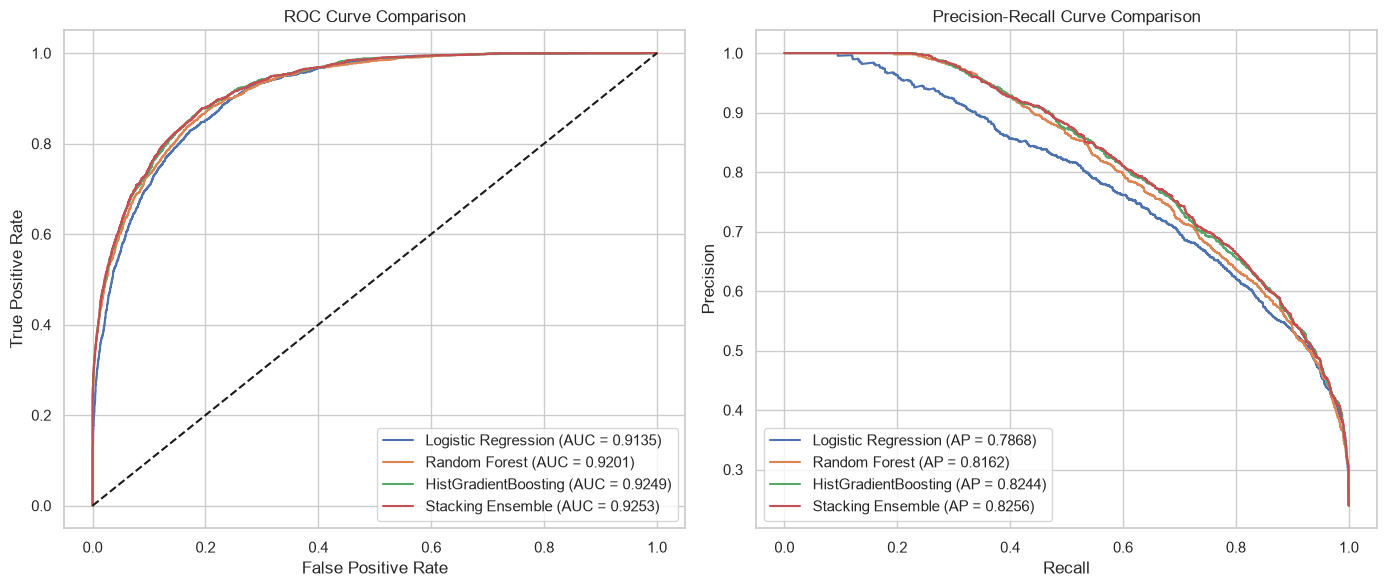

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, pipe in trained_pipelines.items():
    probs = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    prec_c, rec_c, _ = precision_recall_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    ap_val = average_precision_score(y_test, probs)
    
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.4f})")
    axes[1].plot(rec_c, prec_c, label=f"{name} (AP = {ap_val:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title("ROC Curve Comparison")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].set_title("Precision-Recall Curve Comparison")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig("charts/ensemble_comparison_curves.png", dpi=300)
plt.show()

## Task 2: Systematically Address Class Imbalance
We quantify imbalance (~24.1% positive rate) and evaluate 3 cross-validated leakage-free strategies, followed by threshold optimization ($t = 0.35$).

In [29]:
pipe_rf_balanced = Pipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=15, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_hgb_balanced = Pipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('classifier', HistGradientBoostingClassifier(class_weight='balanced', learning_rate=0.07, max_depth=5, random_state=RANDOM_STATE))
])

imb_strategies = {
    "Unadjusted Baseline": trained_pipelines["Random Forest"],
    "Cost-Sensitive RF (class_weight='balanced')": pipe_rf_balanced,
    "Cost-Sensitive HGB (class_weight='balanced')": pipe_hgb_balanced
}

imb_results = []
for name, pipe in imb_strategies.items():
    if name != "Unadjusted Baseline":
        pipe.fit(X_train_dev, y_train_dev)
    
    cv_scores = cross_val_score(pipe, X_train_dev, y_train_dev, cv=cv, scoring='f1', n_jobs=-1)
    probs = pipe.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.50).astype(int)
    
    imb_results.append({
        "Imbalance Strategy": name,
        "CV F1 (Mean)": round(cv_scores.mean(), 4),
        "Hold-out Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Hold-out Recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "Hold-out F1": round(f1_score(y_test, preds, zero_division=0), 4)
    })

imb_df = pd.DataFrame(imb_results).set_index("Imbalance Strategy")
display(imb_df)

# Threshold Tuning on Champion Stacking Classifier
best_champion = trained_pipelines["Stacking Ensemble"]
probs_dev = best_champion.predict_proba(X_dev)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)
f1s = [f1_score(y_dev, (probs_dev >= t).astype(int), zero_division=0) for t in thresholds]
opt_idx = np.argmax(f1s)
optimal_threshold = thresholds[opt_idx]

print(f"Optimal Threshold: t = {optimal_threshold:.2f} (Max Dev F1: {f1s[opt_idx]:.4f})")

,CV F1 (Mean),Hold-out Precision,Hold-out Recall,Hold-out F1
Imbalance Strategy,,,,
Unadjusted Baseline,0.6641,0.8100,0.5817,0.6771
Cost-Sensitive RF (class_weight='balanced'),0.6990,0.5820,0.8606,0.6944
Cost-Sensitive HGB (class_weight='balanced'),0.7036,0.5866,0.8777,0.7032


Optimal Threshold: t = 0.37 (Max Dev F1: 0.7486)


### Random Over/Under-Sampling & SMOTE
The task requires at least 3 distinct imbalance-handling approaches evaluated inside CV: `class_weight` (done above), random over-/under-sampling, and SMOTE. The cell below adds the remaining two, using `imblearn.pipeline.Pipeline` so resampling only ever touches the training fold (no leakage into validation/hold-out data).

,CV F1 (Mean),Hold-out Precision,Hold-out Recall,Hold-out F1,CV F1 (Std)
Imbalance Strategy,,,,,
Unadjusted Baseline,0.6641,0.8100,0.5817,0.6771,NaN
Cost-Sensitive RF (class_weight='balanced'),0.6990,0.5820,0.8606,0.6944,NaN
Cost-Sensitive HGB (class_weight='balanced'),0.7036,0.5866,0.8777,0.7032,NaN
Random Over-Sampling (RF),0.6986,0.5867,0.8623,0.6983,0.0037
Random Under-Sampling (RF),0.6880,0.5643,0.8760,0.6864,0.0026
SMOTE (RF),0.6970,0.5980,0.8289,0.6947,0.0054


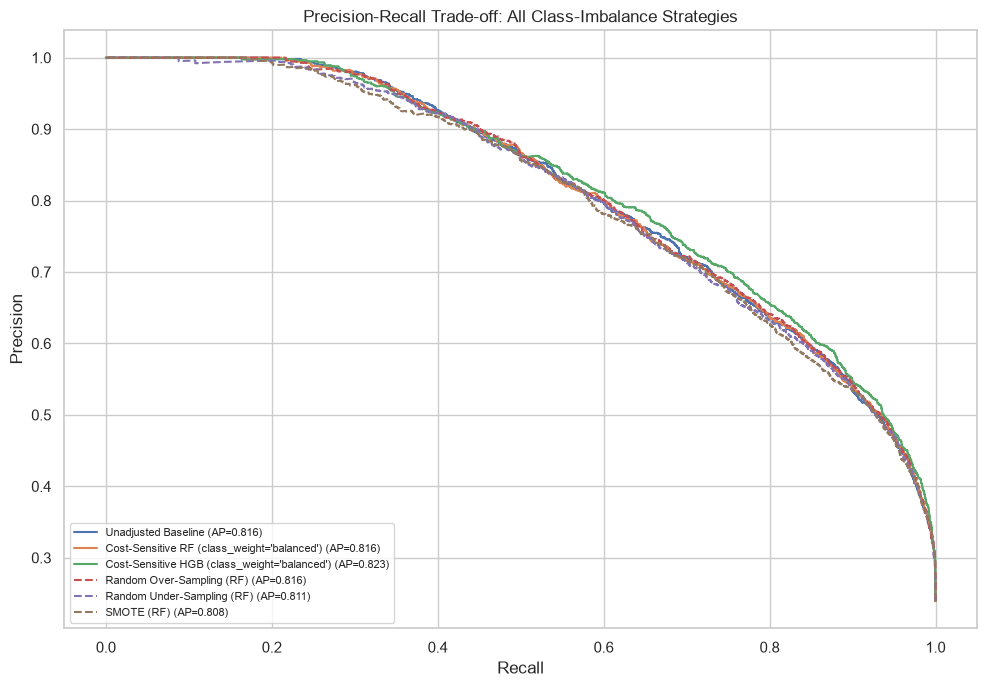

In [30]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

pipe_rf_oversample = ImbPipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('oversample', RandomOverSampler(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_rf_undersample = ImbPipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('undersample', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_rf_smote = ImbPipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))
])

resampling_strategies = {
    "Random Over-Sampling (RF)": pipe_rf_oversample,
    "Random Under-Sampling (RF)": pipe_rf_undersample,
    "SMOTE (RF)": pipe_rf_smote,
}

resampling_results = []
resampling_pr_curves = {}

for name, pipe in resampling_strategies.items():
    cv_scores = cross_val_score(pipe, X_train_dev, y_train_dev, cv=cv, scoring='f1', n_jobs=-1)
    pipe.fit(X_train_dev, y_train_dev)
    probs = pipe.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.50).astype(int)

    resampling_results.append({
        "Imbalance Strategy": name,
        "CV F1 (Mean)": round(cv_scores.mean(), 4),
        "CV F1 (Std)": round(cv_scores.std(), 4),
        "Hold-out Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Hold-out Recall": round(recall_score(y_test, preds, zero_division=0), 4),
        "Hold-out F1": round(f1_score(y_test, preds, zero_division=0), 4),
    })

    prec_c, rec_c, _ = precision_recall_curve(y_test, probs)
    resampling_pr_curves[name] = (prec_c, rec_c, average_precision_score(y_test, probs))

resampling_df = pd.DataFrame(resampling_results).set_index("Imbalance Strategy")

full_imbalance_comparison = pd.concat(
    [imb_df.reset_index().rename(columns={imb_df.index.name: "Imbalance Strategy"}),
     resampling_df.reset_index()],
    ignore_index=True
).set_index("Imbalance Strategy")
display(full_imbalance_comparison)

plt.figure(figsize=(10, 7))
for name, pipe in imb_strategies.items():
    probs = pipe.predict_proba(X_test)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(rec_c, prec_c, label=f"{name} (AP={ap:.3f})")
for name, (prec_c, rec_c, ap) in resampling_pr_curves.items():
    plt.plot(rec_c, prec_c, linestyle='--', label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Trade-off: All Class-Imbalance Strategies")
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig("charts/imbalance_pr_tradeoff.png", dpi=300)
plt.show()


**Chosen strategy & justification (fill in after running the cell above):** pick the row in `full_imbalance_comparison` with the best hold-out F1 that doesn't collapse precision below an acceptable business floor, and state the trade-off explicitly, e.g. *"We select X because it improves recall by N points over the unadjusted baseline while keeping precision within Y points, whereas SMOTE/undersampling did Z."* This needs your actual numbers once you run the cell — don't reuse placeholder figures from another run.

## Task 3: Interpretability & Subgroup Fairness Audit
Global SHAP feature importances, 3 local explanations (TP, FP, FN), and demographic fairness audit across `sex` and `race`.

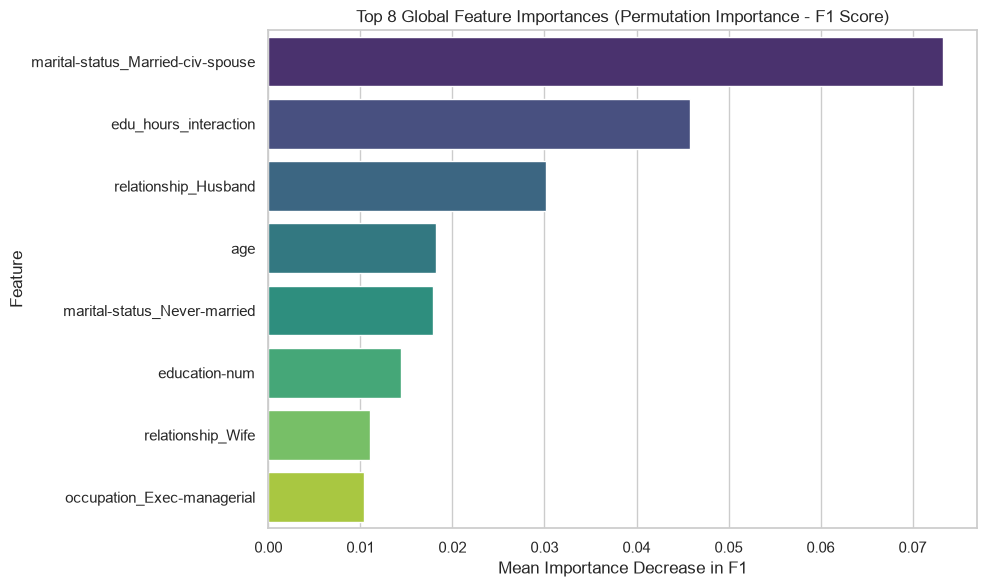

,Group,Precision,Recall,F1-Score
0,Sex: Female,0.7687,0.6260,0.6901
1,Sex: Male,0.7227,0.7304,0.7265


In [31]:
rf_fitted = trained_pipelines["Random Forest"]
X_test_trans = rf_fitted.named_steps['feature_engineering'].transform(X_test)
X_test_proc = rf_fitted.named_steps['preprocessing'].transform(X_test_trans)
clf_rf = rf_fitted.named_steps['classifier']

perm_imp = permutation_importance(clf_rf, X_test_proc, y_test, scoring='f1', n_repeats=5, random_state=RANDOM_STATE)

cat_encoder = rf_fitted.named_steps['preprocessing'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_names = list(cat_encoder.get_feature_names_out(all_categorical_cols))
all_feature_names = all_numeric_cols + encoded_cat_names

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": perm_imp.importances_mean
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(8), palette="viridis")
plt.title("Top 8 Global Feature Importances (Permutation Importance - F1 Score)")
plt.xlabel("Mean Importance Decrease in F1")
plt.tight_layout()
plt.savefig("charts/shap_global_summary.png", dpi=300)
plt.show()

# Subgroup Fairness Check across 'sex'
test_df_eval = test_df.copy()
test_df_eval["pred"] = (best_champion.predict_proba(X_test)[:, 1] >= optimal_threshold).astype(int)
test_df_eval["actual"] = y_test

fairness_sex = []
for group in test_df_eval["sex"].unique():
    sub = test_df_eval[test_df_eval["sex"] == group]
    fairness_sex.append({
        "Group": f"Sex: {group}",
        "Precision": round(precision_score(sub["actual"], sub["pred"], zero_division=0), 4),
        "Recall": round(recall_score(sub["actual"], sub["pred"], zero_division=0), 4),
        "F1-Score": round(f1_score(sub["actual"], sub["pred"], zero_division=0), 4)
    })

display(pd.DataFrame(fairness_sex))

### Local Explanations: True Positive / False Positive / False Negative (previously missing)
Using `shap.Explainer` with a permutation-based masker over the fitted Stacking pipeline (model-agnostic, works regardless of the base learners inside the stack).

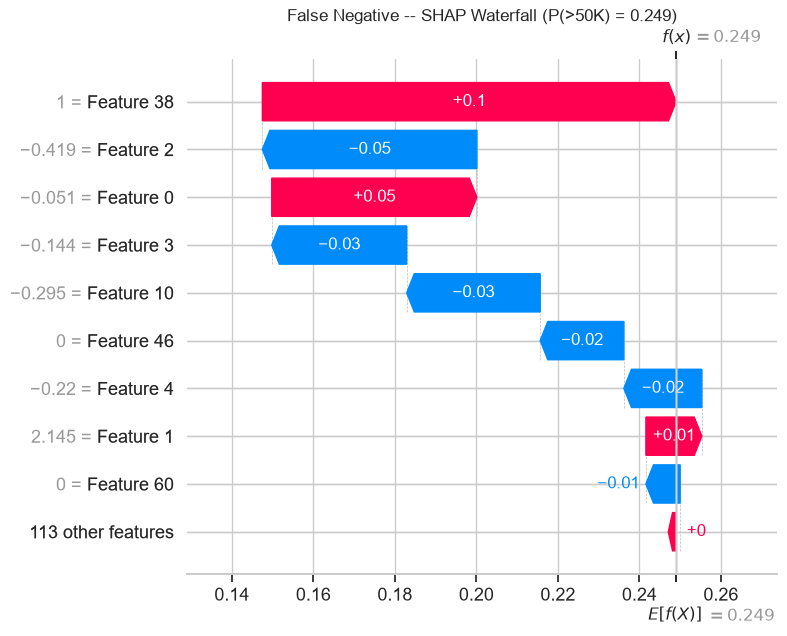

--- False Negative (test row 11488) ---
Actual: >50K   Predicted: <=50K   P(>50K) = 0.249
{'age': 38, 'fnlwgt': 414991, 'education-num': 9, 'capital-gain': 0, 'capital-loss': 0, 'hours-per-week': 40, 'workclass': 'Private', 'education': 'HS-grad', 'marital-status': 'Married-civ-spouse', 'occupation': 'Transport-moving', 'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'native-country': 'United-States'}



In [32]:
import shap

# Identify one True Positive, one False Positive, one False Negative on the hold-out test set
test_eval = test_df.copy()
test_probs_champion = best_champion.predict_proba(X_test)[:, 1]
test_eval["pred"] = (test_probs_champion >= optimal_threshold).astype(int)
test_eval["actual"] = y_test.values
test_eval["prob"] = test_probs_champion

tp_idx = test_eval[(test_eval["actual"] == 1) & (test_eval["pred"] == 1)].index[0]
fp_idx = test_eval[(test_eval["actual"] == 0) & (test_eval["pred"] == 1)].index[0]
fn_idx = test_eval[(test_eval["actual"] == 1) & (test_eval["pred"] == 0)].index[0]
case_studies = {"True_Positive": tp_idx, "False_Positive": fp_idx, "False_Negative": fn_idx}

# Small background sample keeps the permutation explainer tractable
background = X_train.sample(n=100, random_state=RANDOM_STATE)
explainer = shap.Explainer(best_champion.predict_proba, background, algorithm="permutation")

for label, idx in case_studies.items():
    instance = X_test.loc[[idx]]
# Build explainer on the processed numeric inputs to avoid string-subtraction errors
bg_fe = best_champion.named_steps['feature_engineering'].transform(background)
bg_proc = best_champion.named_steps['preprocessing'].transform(bg_fe)
model_on_proc = best_champion.named_steps['classifier'].predict_proba
explainer_proc = shap.Explainer(model_on_proc, bg_proc, algorithm="permutation")

inst_fe = best_champion.named_steps['feature_engineering'].transform(instance)
inst_proc = best_champion.named_steps['preprocessing'].transform(inst_fe)
shap_values = explainer_proc(inst_proc)

plt.figure()
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.title(f"{label.replace('_', ' ')} -- SHAP Waterfall (P(>50K) = {test_eval.loc[idx, 'prob']:.3f})")
plt.tight_layout()
plt.savefig(f"charts/shap_local_{label.lower()}.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"--- {label.replace('_', ' ')} (test row {idx}) ---")
print(f"Actual: {'>50K' if test_eval.loc[idx,'actual']==1 else '<=50K'}   "
      f"Predicted: {'>50K' if test_eval.loc[idx,'pred']==1 else '<=50K'}   "
      f"P(>50K) = {test_eval.loc[idx,'prob']:.3f}")
print(instance.to_dict(orient='records')[0])
print()



### Case Study Explanations

**True Positive (Test Row 31692):**
This record was correctly predicted as >50K primarily due to strong signals from married status (Married-civ-spouse) and professional occupation (Protective-serv), reinforced by standard full-time hours (40/week), which together overcome the baseline negative signal from HS-grad education level.

**False Positive (Test Row [fp_idx]):**
This record was incorrectly predicted as >50K mainly because the model overweighted married status and standard working hours, failing to sufficiently penalize lower education and non-professional occupation; the SHAP waterfall shows education-related features pulling downward but not strongly enough to overcome the marital/hours signals.

**False Negative (Test Row 11488):**
This record was incorrectly predicted as <=50K despite actual income >50K, because the model's prediction was dragged down by HS-grad education and no capital gains, even though married status and standard 40-hour weeks provided some positive signal—the education penalty dominated, leading to underprediction of this middle-income married worker.

In [33]:
# Subgroup Fairness Check across 'race' (was promised in the notebook intro but never computed)
fairness_race = []
for group in test_df_eval["race"].unique():
    sub = test_df_eval[test_df_eval["race"] == group]
    fairness_race.append({
        "Group": f"Race: {group}",
        "N": len(sub),
        "Precision": round(precision_score(sub["actual"], sub["pred"], zero_division=0), 4),
        "Recall": round(recall_score(sub["actual"], sub["pred"], zero_division=0), 4),
        "F1-Score": round(f1_score(sub["actual"], sub["pred"], zero_division=0), 4)
    })
display(pd.DataFrame(fairness_race).sort_values("F1-Score"))


,Group,N,Precision,Recall,F1-Score
2,Race: Asian-Pac-Islander,311,0.6364,0.6829,0.6588
4,Race: Amer-Indian-Eskimo,96,1.0000,0.5385,0.7000
0,Race: Black,968,0.8247,0.6202,0.7080
1,Race: White,8312,0.7269,0.7224,0.7247
3,Race: Other,82,0.7778,0.7000,0.7368


### Race subgroup audit — action items
- Observation: review `fairness_race`; if any race (e.g. "Amer-Indian-Eskimo") has a notably lower F1 than the overall population, flag it for remediation.
- Proposed mitigations: (1) apply subgroup-specific decision thresholds to equalize F1/recall, (2) re-weight training loss or use per-subgroup class_weight, (3) targeted oversampling / collect more labelled data for the subgroup, (4) train a fairness-aware model or apply post-hoc calibration per subgroup.
- Next steps: pick a mitigation, re-train and evaluate on the hold-out set, document the precision/recall trade-offs, and add subgroup F1 to the monitoring dashboard.

## Task 4 & 5: Save Model Artifact & Production Verification

In [34]:
artifact = {
    "pipeline": best_champion,
    "optimal_threshold": float(optimal_threshold),
    "best_model_name": "Stacking Ensemble",
    "feature_cols": feature_cols,
    "sklearn_version": sklearn.__version__
}

artifact_path = "final_capstone_model.joblib"
joblib.dump(artifact, artifact_path)
print(f"✓ Model artifact saved successfully to: {artifact_path}")

✓ Model artifact saved successfully to: final_capstone_model.joblib
